# Cleaning

In [10]:
import pandas as pd
import ast
import string
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Dataset 1: News Articles

In [3]:
google_np = pd.read_csv("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/results/1-Google/1-Newspaper.csv")
google_radio = pd.read_csv("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/results/1-Google/2-Radio.csv")
google_tv = pd.read_csv("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/results/1-Google/3-TV.csv")
google_bc = pd.read_csv("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/results/1-Google/4-Broadcast.csv")

In [4]:
# insert a "media_type" column for all loaded datasets
df_mt = {"newspaper": google_np, "radio": google_radio, "tv": google_tv, "broadcast": google_bc}

for mt, gdf in df_mt.items():
        gdf["media_type"] = mt

# join the datasets together
gog = pd.concat([google_np, google_radio, google_tv, google_bc],ignore_index = True)
gog = gog.sort_values(by = ["publication_date"])

In [5]:
gog.head()

,id,file_path,link,publication_date,title,content,location,media_type
458804,d401f2ce27,/home/jupyter-sc2641/Varshini_FP/3DLNews2/1-Go...,https://vineyardgazette.com/advertise-on-marth...,1995-01-01,The Vineyard Gazette - Martha's Vineyard News ...,Accounts\nAdvertise - Welcome to Marthas Viney...,"{'state': 'Massachusetts', 'city': 'Edgartown'...",newspaper
53701,5619a4c6ab,/home/jupyter-sc2641/Varshini_FP/3DLNews2/1-Go...,https://www.phoenixnewtimes.com/news/education...,1995-01-05,EDUCATION INTERRUPTUS | News | Phoenix | Phoen...,Share this:\nAudio By Carbonatix\n[\n {...,"{'state': 'Arizona', 'city': 'Phoenix', 'longi...",newspaper
1014421,b49ccb45d9,/home/jupyter-sc2641/Varshini_FP/3DLNews2/1-Go...,https://www.dallasobserver.com/news/death-row-...,1995-01-26,Death Row Granny | News | Dallas | Dallas Obse...,Share this:\nAudio By Carbonatix\n[\n {...,"{'state': 'Texas', 'city': 'Dallas', 'longitud...",newspaper
168296,aff26c7f5d,/home/jupyter-sc2641/Varshini_FP/3DLNews2/1-Go...,https://www.westword.com/news/chiffon-part-one...,1995-02-15,CHIFFON PART ONE | News | Denver | Denver West...,Share this:\nAudio By Carbonatix\n[\n {...,"{'state': 'Colorado', 'city': 'Denver', 'longi...",newspaper
168286,158155fb8b,/home/jupyter-sc2641/Varshini_FP/3DLNews2/1-Go...,https://www.westword.com/news/a-wealth-of-trou...,1995-03-15,A WEALTH OF TROUBLE | News | Denver | Denver W...,Share this:\nAudio By Carbonatix\n[\n {...,"{'state': 'Colorado', 'city': 'Denver', 'longi...",newspaper


## Initial Cleaning Steps
- Filter "publication_date" column to keep only articles published between 2013 and 2023
- Unpack the dictionary in the "location" column to gain info on state, city, longitude, latitude
- Separate into two chunks, based on the dates of the surveys we're comparing: survey_1_chunk (2013-2017) and survey_2_chunk (2018-2023)

In [6]:
# data types of each col in gog
gog.info()

<class 'pandas.DataFrame'>
Index: 1880698 entries, 458804 to 1880680
Data columns (total 8 columns):
 #   Column            Dtype
---  ------            -----
 0   id                str  
 1   file_path         str  
 2   link              str  
 3   publication_date  str  
 4   title             str  
 5   content           str  
 6   location          str  
 7   media_type        str  
dtypes: str(8)
memory usage: 5.9 GB


### 1. Filter "publication_date"

In [7]:
gog["publication_date"] = pd.to_datetime(gog["publication_date"], format = "%Y-%m-%d", errors = "coerce")

gog1 = gog[
    (gog["publication_date"] >= pd.Timestamp("2013-01-01")) & (gog["publication_date"] < pd.Timestamp("2018-11-14"))
    ] # survey 1 was conducted between November 14 and 19, 2018

gog2 = gog[
    (gog["publication_date"] >= pd.Timestamp("2018-01-01")) & (gog["publication_date"] < pd.Timestamp("2023-04-13"))
    ] # survey 2 was conducted between April 13 and 17, 2023

Things to note as we go:
- some of the publication_date values do not line up with the actual publication dates displayed in the corresponding links of the articles
- some of the body texts contain bylines (remove later?)
- should we only keep rows with both "title" and "content" values?

In [8]:
dfs = {"gog1": gog1, "gog2": gog2}

for df_name, df in dfs.items():
    print(f"\nInitial information about {df_name}:\n")
    print(df.info())
    print(f"\n\nMissing values in {df_name}: \n{df.isna().sum()}")
    print("----------------------------------------")


Initial information about gog1:

<class 'pandas.DataFrame'>
Index: 439208 entries, 16794 to 1876405
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                439208 non-null  str           
 1   file_path         439208 non-null  str           
 2   link              439208 non-null  str           
 3   publication_date  439208 non-null  datetime64[us]
 4   title             438872 non-null  str           
 5   content           416917 non-null  str           
 6   location          439208 non-null  str           
 7   media_type        439208 non-null  str           
dtypes: datetime64[us](1), str(7)
memory usage: 1.6 GB
None


Missing values in gog1: 
id                      0
file_path               0
link                    0
publication_date        0
title                 336
content             22291
location                0
media_type              0
dtype: int64
---------

### 2. Drop rows with missing "content" values

In [9]:
# drop rows with missing "content" values
for df_name, df in dfs.items():
    df.dropna(subset = "content", inplace = True)
    print(f"Dropped rows with missing content values from {df_name}")

Dropped rows with missing content values from gog1
Dropped rows with missing content values from gog2


### 3. Unpack "location" column

In [10]:
import ast

chunks = []

for df_name, df in dfs.items():
    d = pd.json_normalize(df["location"].map(ast.literal_eval))
    chunk = pd.concat([df, d], axis = 1)
    chunks.append(chunk)

chunk1, chunk2 = chunks

chunks = {"chunk1": chunk1, "chunk2": chunk2}

for chunk_name, chunk in chunks.items():
    chunk.drop(columns = ["location"], inplace = True)

### 4. Drop "file_path" and "link" columns

In [11]:
# drop "file_path" and "link" cols since they're irrelevant to our work
for chunk_name, chunk in chunks.items():
    chunk.drop(columns = ["link", "file_path"], inplace = True)

In [12]:
display(chunk1.info())
display(chunk2.info())

<class 'pandas.DataFrame'>
Index: 416917 entries, 16794 to 1876405
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                416917 non-null  str           
 1   publication_date  416917 non-null  datetime64[us]
 2   title             416847 non-null  str           
 3   content           416917 non-null  str           
 4   media_type        416917 non-null  str           
 5   state             416917 non-null  str           
 6   city              416917 non-null  str           
 7   longitude         416917 non-null  float64       
 8   latitude          416917 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(6)
memory usage: 1.5 GB


None

<class 'pandas.DataFrame'>
Index: 504180 entries, 50542 to 1877300
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                504180 non-null  str           
 1   publication_date  504180 non-null  datetime64[us]
 2   title             504168 non-null  str           
 3   content           504180 non-null  str           
 4   media_type        504180 non-null  str           
 5   state             504180 non-null  str           
 6   city              504180 non-null  str           
 7   longitude         504180 non-null  float64       
 8   latitude          504180 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(6)
memory usage: 1.9 GB


None

### 5. Cleaning "content" column

An example of what a cell in the "content" column looks like:

In [13]:
chunk1["content"].iloc[0]

'JFK watched Crimson Tide win Orange Bowl (This Day in 1963)\nUpdated: Jan. 01, 2013, 11:00 a.m.\nPublished: Jan. 01, 2013, 10:00 a.m.\nBy\nJeremy Gray | jgray@al.com\nAlabama quarterback Joe Namath receives guidance from Coach Paul "Bear" Bryant in this undated photo (Birmingham News file)\nJANUARY 1, 1963 --\xa0 President John F. Kennedy and First Lady Jacqueline Kennedy watched in Miami as Bear Bryant and Joe Namath led the Crimson Tide to a 17-0 Orange Bowl victory over the Oklahoma Sooners.\nRECOMMENDED•al.com\nTuskegee University homecoming shooting: 1 dead, multiple people injured in chaotic sceneNov. 10, 2024, 6:35 a.m.\nThe president presided over the coin toss.On the streets of Birmingham, two black men -- said to be intoxicated and disorderly -- were shot by police after they ran from officers and after one of the men pointed a rifle at police. The men survived.\nThe front page of The News carried a prediction from "Italy\'s noted soothsayers" that during 1963 "the world wil

In [14]:
# remove duplicate articles
for chunk_name, chunk in chunks.items():
    chunk.drop_duplicates(subset = ["content"], inplace = True)

Steps for cleaning the "content" column:
- Remove punctuation, stopwords, special characters, and other weird cases
- Stemming, lemmatization, and tokenization 
- NER (Name-Entity Recognition) to identify

In [15]:
import nltk
from nltk.corpus import stopwords 
nltk.download('stopwords')

[nltk_data] Error loading stopwords: <urlopen error pathsec.urlopen:
[nltk_data]     no validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>


False

In [16]:
from bs4 import BeautifulSoup, Comment

# Custom stopwords
stopwords_custom = ["mr", "ms", "mrs", "th"]

# Create combined stopwords set
stop_set = set(nltk.corpus.stopwords.words('english')) | set(stopwords_custom)

# Identify publication date patterns
date_patterns = [
    # 12/25/2023
    r'\b\d{1,2}/\d{1,2}/\d{2,4}\b',                     
    # 2023-12-25
    r'\b\d{4}-\d{2}-\d{2}\b', 
    # Dec 25, 2023 / December 25 2023
    r'\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\.?\s+\d{1,2},?\s+\d{4}\b',
    # 25 Dec 2023
    r'\b\d{1,2}\s+(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\.?\s+\d{4}\b', 
    # 3:45 PM (timestamps)
    r'\b\d{1,2}:\d{2}\s*(?:AM|PM|am|pm)?\b',
    # "3 hours ago"
    r'\b\d+\s+(?:minute|hour|day|week|month|year)s?\s+ago\b',
    # Weekday + abbreviated/full month date: "Wednesday, Oct. 23, 2013"
    r'\b(?:Mon|Tue|Wed|Thu|Fri|Sat|Sun)[a-z]*,\s*'
    r'(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\.?\s+\d{1,2},?\s+\d{4}\b'
]
# Identify other metadata patterns: byline, metadata phrases, etc. 
meta_patterns = [
    # "By John Smith" on its own line
    r'^\s*By\s+[A-Z][a-zA-Z.\-\' ]+(?:,\s*[A-Z][a-zA-Z.\-\' ]+)*\s*$',
    # "Published on"
    r'\bPublished\s*(?:on|:)?\s*',
    # "Updated on"
    r'\bUpdated\s*(?:on|:)?\s*',
    # "Last (U/u)pdated on"
    r'\bLast\s+[Uu]pdated\s*(?:on|:)?\s*',
    #  "[X] min read"
    r'\b\d+\s+min(?:ute)?\s+read\b',
    # copyright lines
    r'©\s*\d{4}.*?(?:\.|$)',
    r'\bAll [Rr]ights [Rr]eserved\b',
    # Continuation notes: "(Continued from page 20)" / "(Continued on page 5)"
    r'\(Continued\s+(?:from|on)\s+page\s+\d+\)',
    # Wire service datelines: "BISMARCK, N.D. (AP) --" or "NEW YORK (Reuters) —"
    r'\b[A-Z][A-Z\.\s]{2,25},?\s*[A-Z]{1,2}\.?[A-Z]?\.?\s*\((?:AP|Reuters|UPI|AFP)\)\s*[-–—]+\s*',
    # Version of above without the state abbreviated
    r'\b[A-Z][A-Z\.\s]{2,25}\s*\((?:AP|Reuters|UPI|AFP)\)\s*[-–—]+\s*', 
    # Volume/Issue: "Vol. 16--No. 99" / "Vol. 16, No. 99"
    r'\bVol\.?\s*\d+\s*[-–—,]*\s*No\.?\s*\d+\b',
    # Page position: "21 of 35"
    r'\b\d+\s+of\s+\d+\b'
]
# Identidify JSON-leak patterns
json_leak_patterns = [
    r'window\.__[A-Za-z_]+__\s*=.*',  # catches window.__INITIAL_STATE__= ... (if underscores survived)
    r'\b(?:attachmentsReducer|imgSizes|mimeType|postThumbnail|fullWidth)\b.*',  # KQED/WP-specific JSON keys
]

# Compile all date and metadata patterns
all_patterns = re.compile('|'.join(date_patterns + meta_patterns + json_leak_patterns), flags=re.MULTILINE)

# Function to clean articles
def clean_article(text):
    '''
    Function to clean a given text.

    Input: 
    text = string

    Output: 
    Cleaned string

    '''

    # Strip trailing JSON blob
    match = re.search(r'(window\.__\w+__|attachmentsReducer|imgSizes.{0,50}mimeType)', text)
    
    if match:
        text = text[:match.start()]
        
    # Strip HTML tags; keep only visible text
    if isinstance(text, str) and re.search(r'<[a-z]+.*?>', text, re.IGNORECASE):
        soup = BeautifulSoup(text, "html.parser")
        # Remove tags like script, style, etc.
        for tag in soup(["script", "style", "noscript", "iframe"]):
            tag.decompose()
        # Remove HTML comments that have embedded JSON data
        for comment in soup.find_all(string=lambda s: isinstance(s, Comment)):
            comment.extract()
        no_html_text = soup.get_text(separator=" ", strip=True)
    else:
        no_html_text = text

    # Clean up miscoded /control characters
    replacements = {
        # non-breaking space
        '\xa0': ' ', 
        # bullet/control artifact
        '\x95': '', 
        # smart quotes sometimes mis-decoded
        '\x91': "'", '\x92': "'", 
        '\x93': '"', '\x94': '"',
        # en/em dash artifacts
        '\x96': '-', '\x97': '--', 
    }
    
    for bad, good in replacements.items():
        no_html_text = no_html_text.replace(bad, good)

    cleaned = all_patterns.sub('', no_html_text)

    cleaned = re.sub(r'[ \t]+', ' ', cleaned)
    cleaned = re.sub(r'\n\s*\n+', '\n\n', cleaned)
    cleaned = cleaned.strip()

    # Remove digits from string
    text_no_digits = re.sub(r'\d', '', cleaned)

    # Remove punctuation and make string lowercase
    translator = str.maketrans('', '', string.punctuation)
    text_no_punc = text_no_digits.translate(translator).lower()

    # Split into words (tokens) to check individually
    words = text_no_punc.split()

    # Initialize empty list for cleaned tokens
    cleaned_tokens = []

    # Remove stopwords (both pre-defined in the stopwords module and the custom stopwords list defined above)
    cleaned_tokens = [word for word in words if word not in stop_set]

    # Making output a string and not a list
    cleaned_string = ' '.join(cleaned_tokens)
    
    return cleaned_string

In [19]:
# problem_row = chunk[chunk["text_len"] > 100000]["content"].iloc[0]
# print(clean_article(problem_row))
# len(problem_row)

In [20]:
import time

sample = chunks[list(chunks.keys())[0]]["content"].head(20)

start = time.time()
sample.apply(clean_article)
elapsed = time.time() - start

print(f"{elapsed:.2f} sec for 20 rows -> {elapsed/20*1000:.1f} ms/row")

display(len(chunk1))
display(len(chunk2))

0.05 sec for 20 rows -> 2.7 ms/row


378843

450669

In [21]:
# Testing the bult function on a representative test sample
test_sample = pd.concat([
    chunk["content"].sample(100, random_state=42) for chunk in chunks.values()
])

sample_df = list(chunks.values())[0]

# Including some of hte longer articles that we want to clean
sample_df["text_len"] = sample_df["content"].str.len()
worst_cases = sample_df.sort_values("text_len", ascending=False).head(20)["content"]

test_sample = pd.concat([test_sample, worst_cases]).drop_duplicates()

# Apply function
t = test_sample.apply(clean_article)

In [22]:
# Apply clean_article() function to both datasets of articles (takes ~26 mins)
for chunk_name, chunk in chunks.items():
    print(f"Starting {chunk_name}, {len(chunk)} rows...")
    start = time.time()
    chunk["content_cleaned"] = chunk["content"].apply(clean_article)
    print(f"Finished {chunk_name} in {time.time()-start:.1f} sec")

Starting chunk1, 378843 rows...
Finished chunk1 in 651.0 sec
Starting chunk2, 450669 rows...
Finished chunk2 in 873.1 sec


In [23]:
chunk1.head()

,id,publication_date,title,content,media_type,state,city,longitude,latitude,text_len,content_cleaned
16794,fad5150893,2013-01-01,JFK watched Crimson Tide win Orange Bowl (This...,JFK watched Crimson Tide win Orange Bowl (This...,newspaper,Alabama,Birmingham,-86.801904,33.456412,1429,jfk watched crimson tide win orange bowl day j...
87657,aa619e60ff,2013-01-01,Communication is Key to Medication Adherence |...,Open or Close Search Form\nsearch\nChoose what...,newspaper,California,UC-San Francisco,-122.457400,37.763000,3959,open close search form search choose type sear...
90014,4b6cdb61ea,2013-01-01,"February 2013 – Sonoma Sun | Sonoma, CA",Behind the dog show curtain\nPosted on Februar...,newspaper,California,Sonoma,-122.470580,38.277147,2005,behind dog show curtain posted dear dr forsyth...
91038,475d97bec0,2013-01-01,Ventura County Star,Heartwarming moments defy chill at Rose Parade...,newspaper,California,Ventura,-119.301640,34.311203,4426,heartwarming moments defy chill rose parade ra...
164754,80ffad1a1c,2013-01-01,‘Lunch lady’ Sandy Lenhardt has been serving S...,"PUBLISHED:\nJanuary 1, 2013 at 10:55 p.m.\nSur...",newspaper,Colorado,Longmont,-105.100330,40.171484,3715,published pm sure changes school lunch menus y...


In [24]:
chunk1["content_cleaned"].iloc[0]

'jfk watched crimson tide win orange bowl day jeremy gray jgrayalcom alabama quarterback joe namath receives guidance coach paul bear bryant undated photo birmingham news file january president john f kennedy first lady jacqueline kennedy watched miami bear bryant joe namath led crimson tide orange bowl victory oklahoma sooners recommended•alcom tuskegee university homecoming shooting dead multiple people injured chaotic scenenov president presided coin tosson streets birmingham two black men said intoxicated disorderly shot police ran officers one men pointed rifle police men survived front page news carried prediction italys noted soothsayers world remain peace follow jgray follow alcombirmingham purchase product register account link site may receive compensation using site consent user agreement agree clicks interactions personal information may collected recorded andor stored us social media thirdparty partners accordance privacy policy footer navigation'

In [25]:
chunk1["text_len"] = chunk1["content_cleaned"].str.len()
print(chunk1["text_len"].describe())
print(chunk1["text_len"].sort_values(ascending = False).head(10))

count    378843.000000
mean       2370.557701
std        2694.249648
min           0.000000
25%        1006.000000
50%        1861.000000
75%        3048.000000
max      260155.000000
Name: text_len, dtype: float64
863537     260155
863551     215325
842868     212869
838655     199136
842854     197883
842863     190113
1350270    186014
842843     182017
697050     175746
838649     175317
Name: text_len, dtype: int64


In [26]:
chunk2["text_len"] = chunk2["content_cleaned"].str.len()
print(chunk2["text_len"].describe())
print(chunk2["text_len"].sort_values(ascending = False).head(10))

count    450669.000000
mean       2599.471526
std        4737.012918
min           0.000000
25%        1052.000000
50%        1930.000000
75%        3194.000000
max      252676.000000
Name: text_len, dtype: float64
590848     252676
1350270    186014
690598     178445
690512     175153
971805     159254
971789     158144
972548     157948
973225     157578
973209     157554
973228     157543
Name: text_len, dtype: int64


In [27]:
display(chunk1["text_len"].max())
display(chunk2["text_len"].max())

np.int64(260155)

np.int64(252676)

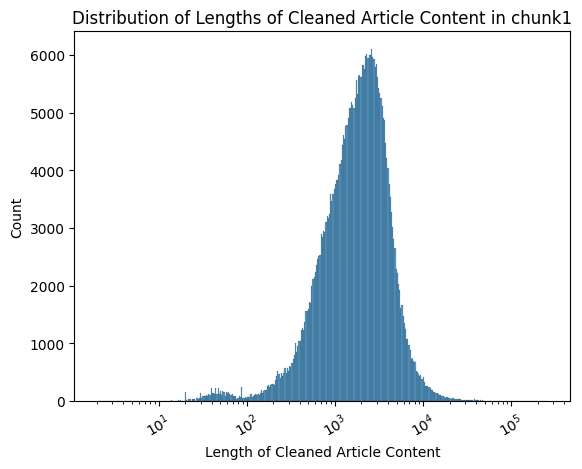

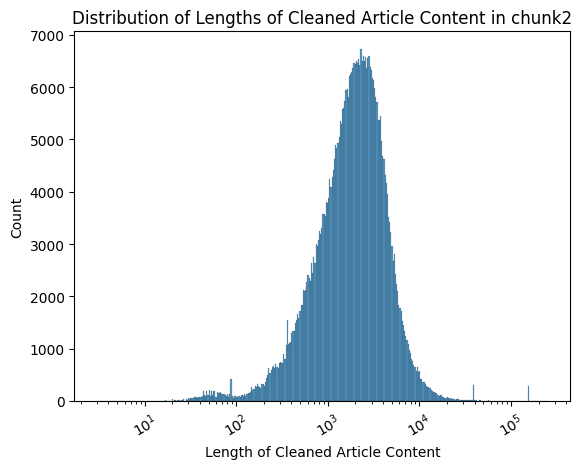

In [28]:
# histogram with chunk text_len
for chunk_name, chunk in chunks.items():
    #sns.histplot(data = chunk[chunk["text_len"] > 50000], x = "text_len")
    sns.histplot(data = chunk, x = "text_len", log_scale = True)
    plt.xticks(rotation = 30)
    plt.xlabel("Length of Cleaned Article Content")
    plt.ylabel("Count")
    plt.title(f"Distribution of Lengths of Cleaned Article Content in {chunk_name}")
    plt.show()

Above, we see that a majority of the articles in the datasets are clustered around 10^3, meaning that most articles contain 1,000-9,999 characters. However, the peak of the distribution is centered around the 2,000-3,000 characters zone. Let's zoom in to the tail to see the outliers.

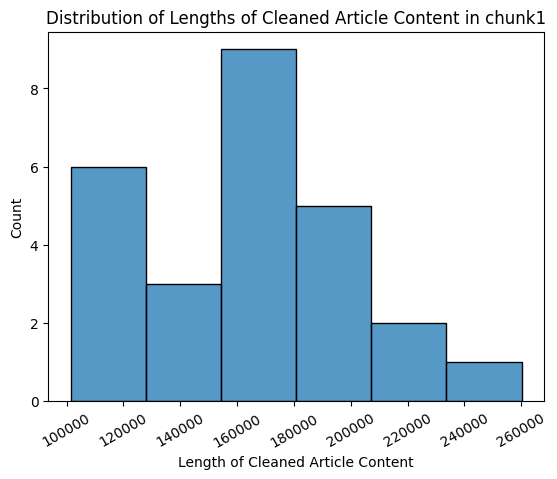

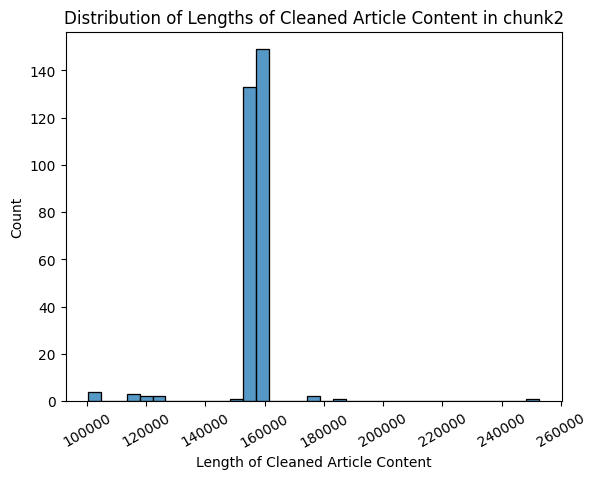

In [29]:
# histogram with chunk text_len
for chunk_name, chunk in chunks.items():
    sns.histplot(data = chunk[chunk["text_len"] > 100000], x = "text_len")
    plt.xticks(rotation = 30)
    plt.xlabel("Length of Cleaned Article Content")
    plt.ylabel("Count")
    plt.title(f"Distribution of Lengths of Cleaned Article Content in {chunk_name}")
    plt.show()

In [30]:
# Drop outliers (articles with 100,000+ characters)
for chunk_name, chunk in chunks.items():
    chunks[chunk_name] = chunk[chunk["text_len"] < 100000]
chunk1 = chunks["chunk1"]
chunk2 = chunks["chunk2"]

In [31]:
display(chunk1["text_len"].max())
display(chunk2["text_len"].max())

np.int64(98146)

np.int64(97880)

In [ ]:
# #Stemming & Lemmatizing
# from nltk.stem import SnowballStemmer
# from nltk.stem import WordNetLemmatizer

# # Need POS tags in order to do WordNetLemmatizer
# from nltk import pos_tag
# from nltk.corpus import wordnet

# stemmer = SnowballStemmer(language = 'english')
# lemmatizer = WordNetLemmatizer()

# def get_pos_tags(tag):
#     '''
#     Function to convert NLTK Parts of Speech tags to WordNet Parts of Speech tags to pass them through WordNerLemmatizer
#     '''

#     if tag.startswith("J"):
#         return wordnet.ADJ
#     elif tag.startswith("V"):
#         return wordnet.VERB
#     elif tag.startswith("N"):
#         return wordnet.NOUN
#     elif tag.startswith("R"):
#         return wordnet.ADV
#     else:
#         return wordnet.NOUN


# def stem_and_lemmatize(text):
#     ''' 
#     Function for stemming and lemmatizing a given text
#     '''

#     words = text.split()
#     # Stem
#     stemmed = [stemmer.stem(w) for w in words]

#     pos_tags = pos_tag(words)
#     # Lemmatize
#     lemmatized = [lemmatizer.lemmatize(w, get_wordnet_pos(tag)) for w, tag in pos_tags]

#     return ' '.join(stemmed), ' '.in(lemmatized)

## Save Articles Dataset

In [32]:
articles = pd.concat([chunk1, chunk2], ignore_index = True)
articles.head()

,id,publication_date,title,content,media_type,state,city,longitude,latitude,text_len,content_cleaned
0,fad5150893,2013-01-01,JFK watched Crimson Tide win Orange Bowl (This...,JFK watched Crimson Tide win Orange Bowl (This...,newspaper,Alabama,Birmingham,-86.801904,33.456412,972,jfk watched crimson tide win orange bowl day j...
1,aa619e60ff,2013-01-01,Communication is Key to Medication Adherence |...,Open or Close Search Form\nsearch\nChoose what...,newspaper,California,UC-San Francisco,-122.457400,37.763000,2958,open close search form search choose type sear...
2,4b6cdb61ea,2013-01-01,"February 2013 – Sonoma Sun | Sonoma, CA",Behind the dog show curtain\nPosted on Februar...,newspaper,California,Sonoma,-122.470580,38.277147,1322,behind dog show curtain posted dear dr forsyth...
3,475d97bec0,2013-01-01,Ventura County Star,Heartwarming moments defy chill at Rose Parade...,newspaper,California,Ventura,-119.301640,34.311203,3171,heartwarming moments defy chill rose parade ra...
4,80ffad1a1c,2013-01-01,‘Lunch lady’ Sandy Lenhardt has been serving S...,"PUBLISHED:\nJanuary 1, 2013 at 10:55 p.m.\nSur...",newspaper,Colorado,Longmont,-105.100330,40.171484,2327,published pm sure changes school lunch menus y...


In [33]:
len(articles)

829188

## Remove Duplicates

In [43]:
articles["id"].duplicated().any()

np.True_

In [44]:
articles = articles.drop_duplicates(subset = ["id"])

## Save Dataset 

In [47]:
articles.to_parquet("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/data/cleaned_articles.parquet")


# Dataset 2: Survey Data

## 1. Climate Change Surveys
Source: AP-NORC (Associated Press-NORC Center for Public Affairs @ University of Chicago). 

Survey 1: "Interviews for this survey were conducted between April 13 and 17, 2023 with adults aged 18 and over
representing the 50 states and the District of Columbia. [...] 1,230 [people] completed the survey."

Survey 2: "Interviews for this survey were conducted between November 14 and 19, 2018, with adults age 18 and
over representing the 50 states and the District of Columbia. [...] 1,202 [people] completed the survey."

In [11]:
survey23 = pd.read_csv("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/surveys/APNORC_april_2023_PUF.csv")
survey18 = pd.read_csv("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/surveys/apnorc_data_epic.csv")

pd.set_option("display.max_columns", None)

In [12]:
print(f"Columns in survey23: \n{survey23.columns}")
print(f"Columns in survey18: \n{survey18.columns}")

Columns in survey23: 
Index(['SU_ID', 'FINALWT', 'SURV_MODE', 'SURV_LANG', 'CUR1', 'CUR3AB', 'B1AB',
       'OFAVA', 'OFAVB', 'OFAVC', 'OFAVD', 'OFAVE', 'OFAVF', 'OFAVG', 'OFAVH',
       'REELECTA', 'REELECTB', 'REELECT2A', 'REELECT2B', 'DJT1', 'DJT2',
       'DJT3', 'DJT4', 'DJT5A', 'DJT5B', 'DJT5C', 'DJT5D', 'KIDS1A', 'KIDS1B',
       'CC6', 'CC7', 'CC8', 'CC12A', 'CC12B', 'CC12C', 'CC12D', 'CC13A',
       'CC13B', 'CC13C', 'CC13D', 'CC13E', 'CC13F', 'CC13G', 'CC13H', 'CC14A',
       'CC14B', 'CC14C', 'CC14D', 'CC14E', 'CC15A', 'CC15B', 'CC15C', 'CC15D',
       'CC15E', 'CC16A', 'CC16B', 'CC16C', 'CC16D', 'CC17A', 'CC17B', 'CC17C',
       'CC17D', 'CC17E', 'CC17F', 'CC17G', 'CC18A', 'CC18B', 'CC18C', 'CC18D',
       'CC19A', 'CC19B', 'CC19C', 'CC19D', 'CC19E', 'CC19F', 'CC19G', 'CC19H',
       'CC20', 'POLITICS', 'DEMO', 'REPUB', 'INDEP', 'IDEO', 'URBAN', 'RELIG',
       'BORN', 'MARITAL', 'AGEGRP', 'EDUCATION', 'RACETH', 'GENDER',
       'HHINCOME', 'STATE', 'CENSUS_REGION'],
      

From these surveys, we will only be keeping the columns we want. These are the relevant qustions from each survey that are identical in both (and can, thus, be compared).

From <b>survey23</b>: 
- SU_ID (Case ID)
- CC6 (Do you think climate change is happening, do you think climate change is not happening, or aren’t you sure?)
- CC7 (Do you think climate change is caused entirely by human activities, caused mostly by human activities, caused about equally by human activities and natural changes in the environment, caused mostly by natural changes in the environment, or caused entirely by natural changes in the environment?)
- CC13A ([Recent extreme weather events, like hurricanes, droughts, floods, unusual heat, or wildfires] In the past five years, how much influence, if any, has each of the following had when it comes to informing your views about climate change?
- CC13B (In the past five years, how much influence, if any, has each of the following had when it comes to informing your views about climate change?)
- CC13D ([Political leaders] In the past five years, how much influence, if any, has each of the following had when it comes to informing your views about climate change?)
- POLITICS (Do you consider yourself a Democrat, a Republican, an independent or none of these?)
- MARITAL (Marital status)
- AGEGRP (Age)
- EDUCATION (Educational attainment)
- RACETH (Race/ethnicity)
- GENDER (Gender)
- HHINCOME (Household income)
- STATE (State of residence)
- CENSUS_REGION (Census region)
- CC8 (Over the past year, have you become more concerned about climate change, less concerned, or has there been no change?) (NOTE: This question is not in <b>survey18</b>)

From <b> survey18</b>: 
- SU_ID (Case ID)
- Q18 (Do you think climate change is happening, do you think climate change is not happening, or aren’t you sure?)
- Q19 (Do you think climate change is caused entirely by human activities, caused mostly by human activities, caused about equally by human activities and natural changes in the environment, caused mostly by natural changes in the environment, or caused entirely by natural changes in the environment?)
- Q22A ([Recent extreme weather events, like hurricanes, droughts, floods, unusual heat] In the past five years, how much influence, if any, have the following had on your views about the science on climate change?)
- Q22B (In the past five years, how much influence, if any, has each of the following had when it comes to informing your views about climate change?)
- Q22F ([The views of political leaders] In the past five years, how much influence, if any, have the following had on your views about the science on climate change?)
- POLITICS (Do you consider yourself a Democrat, a Republican, an independent or none of these?)
- MARITAL (Marital status)
- AGEGRP (Age)
- EDUCATION (Educational attainment)
- RACETH (Race/ethnicity)
- GENDER (Gender)
- HHINCOME (Household income)
- STATE (State of residence)
- CENSUS_REGION (Census region)
- Q21 (Do you find the science on climate change more convincing than five years ago, just about the same, or less convincing?) (NOTE: This question is not in <b>survey23</b>)

In [13]:
survey23 = survey23[["SU_ID", "CC6", "CC7", "CC13A", "CC13B", "CC13D",
                     "POLITICS", "MARITAL", "AGEGRP", "EDUCATION", "RACETH", "GENDER", "HHINCOME", "STATE", "CENSUS_REGION", 
                     "CC8"]]
survey18 = survey18[["SU_ID", "Q18", "Q19", "Q22A", "Q22B", "Q22F",
                    "POLITICS", "MARITAL", "agegrp", "EDUCATION", "RACETH", "GENDER", "HHINCOME", "STATE", "CENSUS_REGION", 
                     "Q21"]]
survey18.rename(columns = {"agegrp": "AGEGRP"}, inplace = True)

In [14]:
print(f"Missing values in survey23: \n{survey23.isna().sum()}")
print(f"Missing values in survey18: \n{survey18.isna().sum()}")

Missing values in survey23: 
SU_ID              0
CC6                0
CC7              322
CC13A              0
CC13B              0
CC13D              0
POLITICS           0
MARITAL            0
AGEGRP             0
EDUCATION          0
RACETH             0
GENDER             0
HHINCOME           0
STATE              0
CENSUS_REGION      0
CC8                0
dtype: int64
Missing values in survey18: 
SU_ID              0
Q18                0
Q19              337
Q22A               0
Q22B               0
Q22F               0
POLITICS           0
MARITAL            0
AGEGRP             0
EDUCATION          0
RACETH             0
GENDER             0
HHINCOME           0
STATE              0
CENSUS_REGION      0
Q21                0
dtype: int64


Zooming in on the unique values in each column to deal with edge cases, missing values, etc.

First, let's take a look at Q18, Q19 from survey18 and CC6, CC7 from survey23.

In [15]:
print("CC6 and CC7 from SURVEY23:")
display(pd.crosstab(survey23["CC6"], survey23["CC7"], dropna = False))

print("Q18 and Q19 from SURVEY18:")
display(pd.crosstab(survey18["Q18"], survey18["Q19"], dropna = False))

CC6 and CC7 from SURVEY23:


CC7,(1) Caused entirely by human activites,(2) Caused mostly by human activites,(3) Caused equally by human activites and natural changes in the environment,(4) Caused mostly by natural changes in the environment,(5) Caused entirely by natural changes in the environment,(99) DON'T KNOW/SKIPPED ON WEB/REFUSED (VOL),NaN
CC6,,,,,,,
(1) Climate change is happening,141,438,257,58,8,6,0
(2) Climate change is not happening,0,0,0,0,0,0,136
(77) Not sure if climate change is happening,0,0,0,0,0,0,182
(99) SKIPPED ON WEB/REFUSED (VOL),0,0,0,0,0,0,4


Q18 and Q19 from SURVEY18:


Q19,(1) Caused entirely by human activities,(2) Caused mostly by human activities,(3) Caused equally by human activities and natural changes in the environment,(4) Caused mostly by natural changes in the environment,(5) Caused entirely by natural changes in the environment,(99) DON'T KNOW/SKIPPED/ REFUSED (VOL),NaN
Q18,,,,,,,
(1) Climate change is happening,108,419,243,75,19,1,0
(2) Climate change is not happening,0,0,0,0,0,0,113
(77) Not sure if climate change is happening,0,0,0,0,0,0,216
(99) SKIPPED/REFUSED (VOL),0,0,0,0,0,0,8


In [16]:
# Removing leading and trailing whitespaces 
survey23 = survey23.replace(r"^ +| +$", r"", regex = True)
survey18 = survey18.replace(r"^ +| +$", r"", regex = True)

In [17]:
import numpy as np

# Making sure the values in survey23 the same as survey18
survey23["CC6"] = np.where(survey23["CC6"] == "(99) SKIPPED ON WEB/REFUSED (VOL)", "(99) SKIPPED/REFUSED (VOL)", survey23["CC6"])
survey23["CC7"] = np.where(survey23["CC7"] == "(99) DON'T KNOW/SKIPPED ON WEB/REFUSED (VOL)", "(99) DON'T KNOW/SKIPPED/ REFUSED (VOL)", survey23["CC7"])


In [18]:
# Convert missing values in CC7 to "(99)" in Survey23 and in Q19 to "(99)" in Survey18
# For example: in Survey18, if Q18 is not equal to 99 and if q19 is nan then convert the nans to 99

convert_list = [(survey23, ["CC6", "CC7"]), (survey18, ["Q18", "Q19"])]
label = "(99) DON'T KNOW/SKIPPED/ REFUSED (VOL)"

for df, (q1, q2) in convert_list:
    condition = (df[q1] != label) & (df[q2].isna())
    print(q2, "rows to fill:", condition.sum())
    df.loc[condition, q2] = label

CC7 rows to fill: 322
Q19 rows to fill: 337


In [19]:
# Aligning the "(99) ..." value counts from both datasets for the concerned questions' columns
col_list_to_fix = ["CC13A", "CC13B", "CC13D"]
pref_label = "(99) DON'T KNOW/SKIPPED/ REFUSED (VOL)"

for col in col_list_to_fix:
    condition = (survey23[col] == "(99) DON'T KNOW/SKIPPED ON WEB/REFUSED (VOL)")
    survey23.loc[condition, col] = pref_label
    print(col, "rows filled:", condition.sum())

CC13A rows filled: 9
CC13B rows filled: 15
CC13D rows filled: 22


In [20]:
# Align the column names in Survey18 and Survey23
display(survey23.columns)
display(survey18.columns)

cols_to_change_23 = {"CC6": "cc_happening", "CC7": "cc_cause", "CC13A": "influence_extreme_weather", "CC13B": "influence_news_coverage", "CC13D": "influence_political_leaders", "CC8": "cc_personal_concern"} 
cols_to_change_18 = {"Q18": "cc_happening", "Q19": "cc_cause", "Q22A": "influence_extreme_weather", "Q22B": "influence_news_coverage", "Q22F": "influence_political_leaders", "Q21": "cc_science_convincing"} 
surveys = [(survey23, cols_to_change_23), (survey18, cols_to_change_18)]

for survey, cols in surveys:
    survey.rename(columns = cols, inplace = True)

# make the other column names lowercase
survey23.rename(str.lower, axis = "columns", inplace = True)
survey18.rename(str.lower, axis = "columns", inplace = True)

# Create a new column in both datasets called "wave" to identify which survey the respondent belongs in
survey23["wave"] = "Survey 2023"
survey18["wave"] = "Survey 2018"

# Concatenate the two survey datasets
cc_survey = pd.concat([survey23, survey18], ignore_index = True, sort = False)


Index(['SU_ID', 'CC6', 'CC7', 'CC13A', 'CC13B', 'CC13D', 'POLITICS', 'MARITAL',
       'AGEGRP', 'EDUCATION', 'RACETH', 'GENDER', 'HHINCOME', 'STATE',
       'CENSUS_REGION', 'CC8'],
      dtype='str')

Index(['SU_ID', 'Q18', 'Q19', 'Q22A', 'Q22B', 'Q22F', 'POLITICS', 'MARITAL',
       'AGEGRP', 'EDUCATION', 'RACETH', 'GENDER', 'HHINCOME', 'STATE',
       'CENSUS_REGION', 'Q21'],
      dtype='str')

In [21]:
cc_survey.head()

,su_id,cc_happening,cc_cause,influence_extreme_weather,influence_news_coverage,influence_political_leaders,politics,marital,agegrp,education,raceth,gender,hhincome,state,census_region,cc_personal_concern,wave,cc_science_convincing
0,55,(1) Climate change is happening,(3) Caused equally by human activites and natu...,(2) A lot of influence,(4) Not much influence,(5) No influence,(3) Independent,(1) Married,(5) 65+,(4) College graduate or above,(1) White,(1) Male,"(8) $100,000 to under $150,000",VA. Virginia,(3) South,(3) No change,Survey 2023,NaN
1,66,(1) Climate change is happening,(3) Caused equally by human activites and natu...,(2) A lot of influence,(3) A moderate amount of influence,(4) Not much influence,(1) Democrat,(1) Married,(4) 60 to 65,(3) Some college,(1) White,(1) Male,"(8) $100,000 to under $150,000",NJ. New Jersey,(1) Northeast,(1) More concerned,Survey 2023,NaN
2,79,(1) Climate change is happening,(2) Caused mostly by human activites,(2) A lot of influence,(3) A moderate amount of influence,(3) A moderate amount of influence,(3) Independent,(1) Married,(5) 65+,(4) College graduate or above,(1) White,(2) Female,"(9) $150,000 or more",FL. Florida,(3) South,(1) More concerned,Survey 2023,NaN
3,80,(1) Climate change is happening,(1) Caused entirely by human activites,(2) A lot of influence,(3) A moderate amount of influence,(4) Not much influence,(3) Independent,(5) Never married,(2) 30 to 39,(3) Some college,(1) White,(1) Male,"(7) $75,000 to under $100,000",CO. Colorado,(4) West,(3) No change,Survey 2023,NaN
4,86,(2) Climate change is not happening,(99) DON'T KNOW/SKIPPED/ REFUSED (VOL),(5) No influence,(5) No influence,(5) No influence,(2) Republican,(5) Never married,(2) 30 to 39,(4) College graduate or above,(1) White,(1) Male,"(4) $30,000 to under $40,000",NY. New York,(1) Northeast,(3) No change,Survey 2023,NaN


Exploring the "cc_personal_concern" and "cc_science_convincing" columns:

/tmp/ipykernel_165649/4047481240.py:3: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data = cc_survey[cc_survey["wave"] == "Survey 2023"], x = "cc_personal_concern", hue = "cc_personal_concern", legend = False, palette = ["#2e8b57"])
/tmp/ipykernel_165649/4047481240.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0, ha='center')


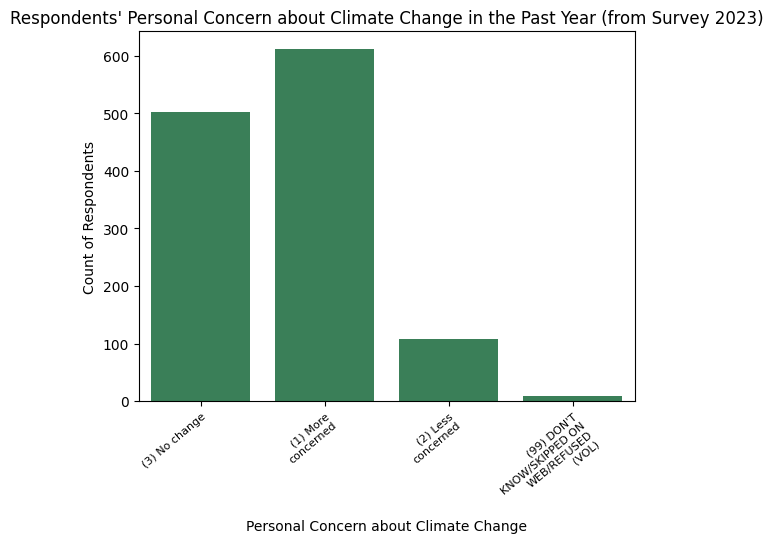

In [22]:
# EDA on cc_personal_concern

sns.countplot(data = cc_survey[cc_survey["wave"] == "Survey 2023"], x = "cc_personal_concern", hue = "cc_personal_concern", legend = False, palette = ["#2e8b57"])

import textwrap
ax = plt.gca()
labels = [textwrap.fill(label.get_text(), 15) for label in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=0, ha='center')

plt.xticks(rotation = 40, ha = "right", rotation_mode = "anchor", fontsize = 8)
plt.xlabel("Personal Concern about Climate Change")
plt.ylabel("Count of Respondents")
plt.title("Respondents' Personal Concern about Climate Change in the Past Year (from Survey 2023)")
plt.show()

In [23]:
print(repr(cc_survey.columns.tolist()))

['su_id', 'cc_happening', 'cc_cause', 'influence_extreme_weather', 'influence_news_coverage', 'influence_political_leaders', 'politics', 'marital', 'agegrp', 'education', 'raceth', 'gender', 'hhincome', 'state', 'census_region', 'cc_personal_concern', 'wave', 'cc_science_convincing']


/tmp/ipykernel_165649/168603251.py:3: UserWarning: 
The palette list has fewer values (1) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(cc_survey[cc_survey["wave"] == "Survey 2018"], x = "cc_science_convincing", hue = "cc_science_convincing", legend = False, palette = ["#2e8b57"])
/tmp/ipykernel_165649/168603251.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0, ha='center')


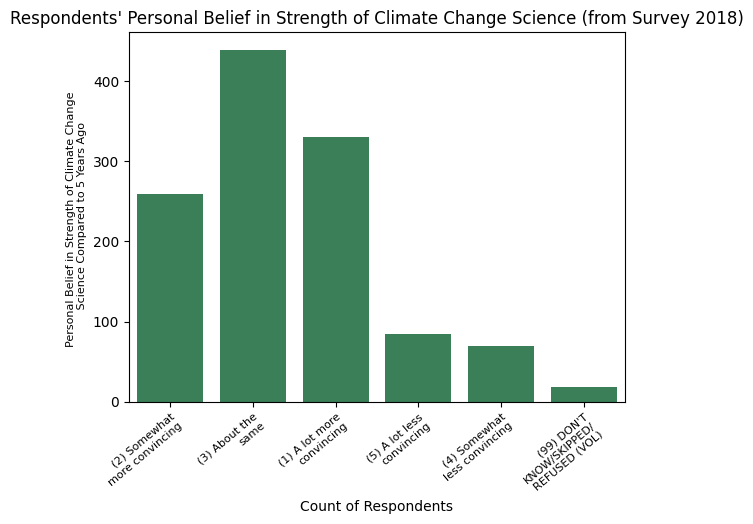

In [24]:
# EDA on cc_science_convincing

sns.countplot(cc_survey[cc_survey["wave"] == "Survey 2018"], x = "cc_science_convincing", hue = "cc_science_convincing", legend = False, palette = ["#2e8b57"])

import textwrap
ax = plt.gca()
labels = [textwrap.fill(label.get_text(), 15) for label in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=0, ha='center')

plt.xticks(rotation = 40, ha = "right", rotation_mode = "anchor", fontsize = 8)
plt.xlabel("Count of Respondents")
plt.ylabel("Personal Belief in Strength of Climate Change \n Science Compared to 5 Years Ago", fontsize = 8)
plt.title("Respondents' Personal Belief in Strength of Climate Change Science (from Survey 2018)")
plt.show()

In [25]:
# Drop cc_personal_concern, cc_science_convincing
cc_survey = cc_survey.drop(["cc_personal_concern", "cc_science_convincing"], axis = 1)

In [26]:
cc_survey.isna().sum()

su_id                          0
cc_happening                   0
cc_cause                       0
influence_extreme_weather      0
influence_news_coverage        0
influence_political_leaders    0
politics                       0
marital                        0
agegrp                         0
education                      0
raceth                         0
gender                         0
hhincome                       0
state                          0
census_region                  0
wave                           0
dtype: int64

In [27]:
# For each value, split the code from the text 
import re

def parse_code_text(val):
    '''
    Function to separate the survey response code and its corresponding text

    Input: val = value to parse for code and text
    '''

    # Reg Ex to identify the distinction between codes (in parentheses in the value) and the text
    match = re.match(r"\((\d+)\)\s*(.*)", val)

    # Find and split codes and corresponding texts
    if match:
        code, text = match.groups()
        return int(code), str(text).strip()
    
    return None, val

In [28]:
for col in cc_survey.columns.drop("su_id"):
    parsed = cc_survey[col].apply(lambda x: pd.Series(parse_code_text(x)))
    cc_survey[f"{col}_code"] = parsed[0]
    cc_survey[f"{col}_text"] = parsed[1]

In [29]:
cc_survey = cc_survey.drop(['cc_happening', 'cc_cause', 'influence_extreme_weather',
       'influence_news_coverage', 'influence_political_leaders', 'politics',
       'marital', 'agegrp', 'education', 'raceth', 'gender', 'hhincome',
       'state', 'census_region','wave', 'wave_code'], axis = 1)

In [30]:
# Recode "99" in the code columns as NaNs

code_cols = ['cc_happening_code', 'cc_cause_code', 
             'influence_extreme_weather_code', 'influence_news_coverage_code', 'influence_political_leaders_code', 
             'politics_code', 'marital_code', 'agegrp_code', 'education_code', 'raceth_code', 'gender_code', 'hhincome_code',
             'state_code', 'census_region_code']

for col in cc_survey.columns.drop("su_id"):
    if col in code_cols:
        cc_survey[col] = np.where(cc_survey[col] == 99, np.nan, cc_survey[col])
        #cc_survey[col] = cc_survey[col].astype("Int64")
        #cc_survey[col] = cc_survey[col].where(cc_survey[col].notna(), np.nan)    
    else: 
        continue

In [31]:
# Clean "hhincome" 
cc_survey["hhincome_text"] = cc_survey["hhincome_text"].str.replace("$", "")

# Keep code or text, not both, for each column
cc_survey = cc_survey[["su_id", "cc_happening_text", "cc_cause_text", 
"influence_extreme_weather_code", "influence_news_coverage_code", "influence_political_leaders_code",
"politics_text", "marital_text", "agegrp_text", "education_text", "raceth_text", "gender_text", "hhincome_text", 
"state_text", "census_region_text", "wave_text"]]

In [32]:
cc_survey.head()

,su_id,cc_happening_text,cc_cause_text,influence_extreme_weather_code,influence_news_coverage_code,influence_political_leaders_code,politics_text,marital_text,agegrp_text,education_text,raceth_text,gender_text,hhincome_text,state_text,census_region_text,wave_text
0,55,Climate change is happening,Caused equally by human activites and natural ...,2.0,4.0,5.0,Independent,Married,65+,College graduate or above,White,Male,"100,000 to under 150,000",VA. Virginia,South,Survey 2023
1,66,Climate change is happening,Caused equally by human activites and natural ...,2.0,3.0,4.0,Democrat,Married,60 to 65,Some college,White,Male,"100,000 to under 150,000",NJ. New Jersey,Northeast,Survey 2023
2,79,Climate change is happening,Caused mostly by human activites,2.0,3.0,3.0,Independent,Married,65+,College graduate or above,White,Female,"150,000 or more",FL. Florida,South,Survey 2023
3,80,Climate change is happening,Caused entirely by human activites,2.0,3.0,4.0,Independent,Never married,30 to 39,Some college,White,Male,"75,000 to under 100,000",CO. Colorado,West,Survey 2023
4,86,Climate change is not happening,DON'T KNOW/SKIPPED/ REFUSED (VOL),5.0,5.0,5.0,Republican,Never married,30 to 39,College graduate or above,White,Male,"30,000 to under 40,000",NY. New York,Northeast,Survey 2023


## Save the dataset

In [33]:
cc_survey.to_csv("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/data/cleaned_cc_survey.csv")

## 2. Local News Surveys

Source: Pew Research Center

Survey 1: 

Survey 2: 